# Enhancement Citra Satelit – Domain Spasial

---

## Pipeline Utama

```
citra_input.png (uint16, sangat gelap)
       |
1. Baca citra sebagai uint16
       |
2. Masking background (piksel = 0)
       |
3. Contrast Stretching (percentile 1%-99%)
       |
4. RGB → HSI
       |
5. Enhancement: I^0.80, S x1.35, H tetap
       |
6. HSI → RGB
       |
citra_output_enhanced.png
```


---

## 1. Import Library


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")
print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)


Libraries loaded successfully!
OpenCV version: 5.0.0
NumPy version: 2.1.3


---

## 2. Membaca Citra Input



In [15]:
INPUT_PATH     = "citra_input.png"
OUTPUT_PATH    = "citra_output_enhanced.png"
REFERENCE_PATH = "contoh_output.png"

bgr_raw = cv2.imread(INPUT_PATH, cv2.IMREAD_UNCHANGED)

if bgr_raw is None:
    raise FileNotFoundError("File tidak ditemukan: " + INPUT_PATH)

print("shape:", bgr_raw.shape)
print("Tipe data           :", bgr_raw.dtype)
print("Nilai min           :", bgr_raw.min())
print("Nilai max           :", bgr_raw.max())
print("Rata-rata           :", round(float(bgr_raw.mean()), 2))


shape: (7831, 7711, 3)
Tipe data           : uint16
Nilai min           : 0
Nilai max           : 56601
Rata-rata           : 6096.27


---

## 3. Visualisasi Citra Input





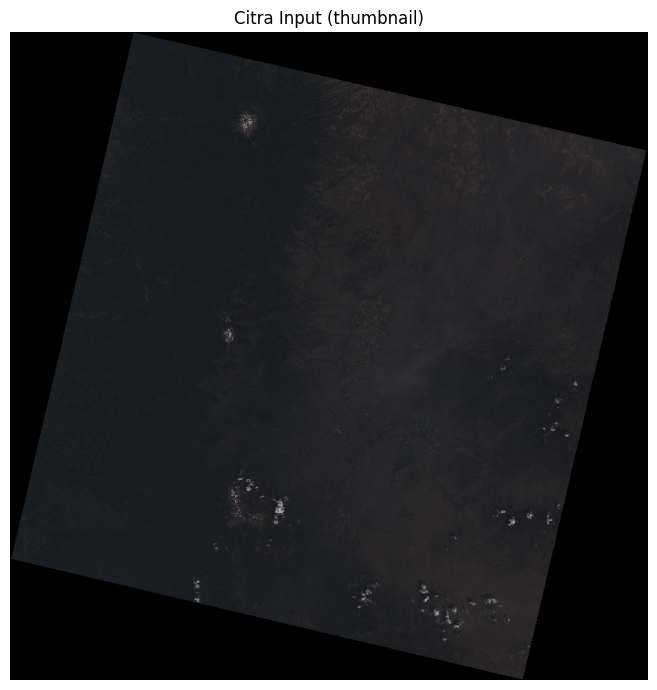

Resolusi asli: 7711 x 7831 piksel


In [3]:
# thumbnail dengan ukuran 800 pixel untuk visualisasi cepat karena ukuran file besar
THUMB_SIZE = 800
scale = THUMB_SIZE / max(bgr_raw.shape[:2])
thumb_raw = cv2.resize(bgr_raw, (0, 0), fx=scale, fy=scale)

if thumb_raw.dtype == np.uint16:
    thumb_8bit = (thumb_raw / 256).astype(np.uint8)
else:
    thumb_8bit = thumb_raw.astype(np.uint8)

thumb_rgb = cv2.cvtColor(thumb_8bit, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 7))
plt.imshow(thumb_rgb)
plt.title("Citra Input (thumbnail)")
plt.axis("off")
plt.tight_layout()
plt.show()
print("Resolusi asli:", bgr_raw.shape[1], "x", bgr_raw.shape[0], "piksel")


---

## 4. Analisis Histogram Citra Input




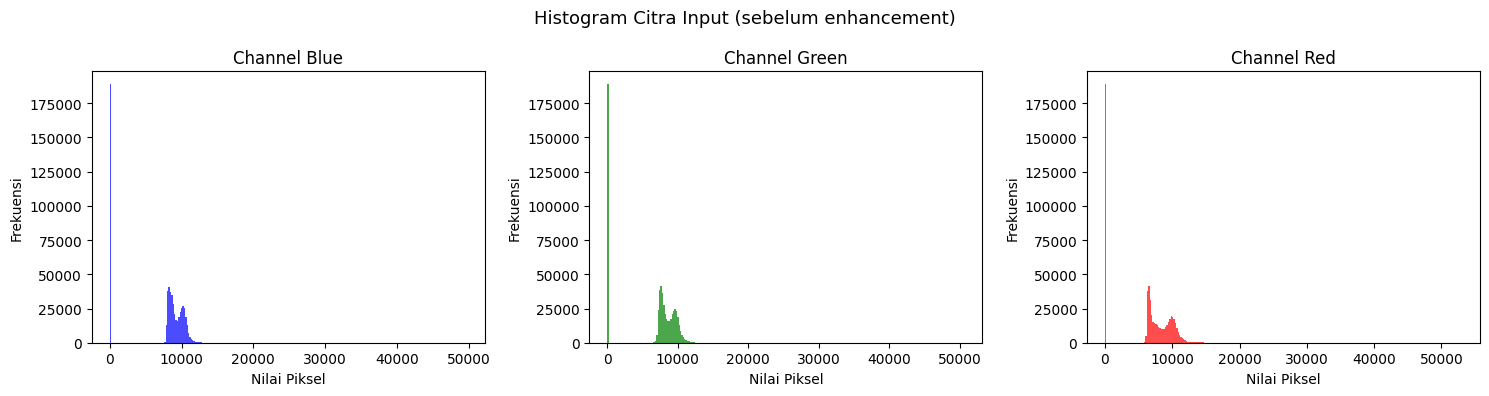

Distribusi yang terkonsentrasi di rentang rendah = citra terlalu gelap.


In [4]:
sub = bgr_raw[::10, ::10]  # sampling setiap 10 pixel untuk cek distribusi channel

channels = ["Blue", "Green", "Red"]
colors   = ["blue", "green", "red"]

# plot tiap channel dalam histogram
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (ch_name, color) in enumerate(zip(channels, colors)):
    ch = sub[:, :, i].flatten()
    axes[i].hist(ch, bins=256, color=color, alpha=0.7)
    axes[i].set_title("Channel " + ch_name)
    axes[i].set_xlabel("Nilai Piksel")
    axes[i].set_ylabel("Frekuensi")

fig.suptitle("Histogram Citra Input (sebelum enhancement)", fontsize=13)
plt.tight_layout()
plt.show()
print("Distribusi yang terkonsentrasi di rentang rendah = citra terlalu gelap.")


---

## 5. Masking Background Hitam

untuk background dengan warna biru = 0, dikecualikan dari proses contrast stretching agar tidak ikut bergeser. diambil biru = 0 karena diasumsikan ini adalah warna background


In [5]:
valid_mask = bgr_raw[:, :, 0] > 0 # ambil hanya pixel dengan channel blue > 0

total_pixels = bgr_raw.shape[0] * bgr_raw.shape[1]
valid_pixels = int(valid_mask.sum())
print("Total pixel    :", total_pixels)
print("Piksel valid    :", valid_pixels, "("+str(round(100*valid_pixels/total_pixels, 1))+"%)")
print("Pixel background:", total_pixels - valid_pixels)


Total pixel    : 60384841
Piksel valid    : 41637460 (69.0%)
Pixel background: 18747381


---

## 6. Contrast Stretching (Normalisasi Percentile)

Untuk setiap channel, rentang intensitas dipetakan ke `[0, 1]` menggunakan percentile 1% dan 99%:

$$I_{norm} = \operatorname{clip}\left(\frac{I - p_{1\%}}{p_{99\%} - p_{1\%}},\; 0,\; 1\right)$$


1% dan 99% digunakan untuk menghindari noise karena outlier


In [6]:
def contrast_stretch(bgr_img, valid_mask, low_pct=1, high_pct=99):
    bgr_f = bgr_img.astype(np.float64)
    out   = np.zeros_like(bgr_f)
    ch_names = ["B", "G", "R"]

    for ch in range(3):
        channel    = bgr_f[:, :, ch]
        valid_vals = channel[valid_mask]
        p_low  = np.percentile(valid_vals, low_pct)
        p_high = np.percentile(valid_vals, high_pct)
        print("  Channel", ch_names[ch], ": p"+str(low_pct)+"% =", round(p_low, 1), ", p"+str(high_pct)+"% =", round(p_high, 1))
        denom = (p_high - p_low) if (p_high - p_low) > 0 else 1.0
        out[:, :, ch] = np.clip((channel - p_low) / denom, 0.0, 1.0)

    out[~valid_mask] = 0.0  # pertahankan background = 0
    return out


print("=== Contrast Stretching ===")
bgr_norm = contrast_stretch(bgr_raw, valid_mask)
print()
print("Setelah normalisasi (pixel valid):")
print("  Min :", round(float(bgr_norm[valid_mask].min()), 4))
print("  Max :", round(float(bgr_norm[valid_mask].max()), 4))
print("  Mean:", round(float(bgr_norm[valid_mask].mean()), 4))


=== Contrast Stretching ===
  Channel B : p1% = 7902.0 , p99% = 11871.0
  Channel G : p1% = 7070.0 , p99% = 11745.0
  Channel R : p1% = 6210.0 , p99% = 13308.0

Setelah normalisasi (pixel valid):
  Min : 0.0
  Max : 1.0
  Mean: 0.3346


---

## 7. Transformasi RGB → HSI


**Intensity:**
$$I = \frac{R+G+B}{3}$$

**Saturation:**
$$S = 1 - \frac{3\,\min(R,G,B)}{R+G+B+\epsilon}$$

**Hue:**
$$\theta = \arccos\left(\frac{\frac{1}{2}[(R-G)+(R-B)]}{\sqrt{(R-G)^2+(R-B)(G-B)}+\epsilon}\right)$$

$$H = \begin{cases} \theta & \text{jika } B \le G \\ 360^\circ - \theta & \text{jika } B > G \end{cases}$$ <br> <br>HSI memisahkan  warna (H, S) dan kecerahan (I) sehingga keduanya dapat dianalisis secara independen. Konversi ke HSI dilakukan setelah contrast stretching dan normalisasi karena rumus HSI membutuhkan input RGB pada skala 0 sampai 1

In [7]:
def rgb_to_hsi(bgr_norm):

    eps = 1e-10
    R = bgr_norm[:, :, 2].copy()
    G = bgr_norm[:, :, 1].copy()
    B = bgr_norm[:, :, 0].copy()

    # Intensity
    I = (R + G + B) / 3.0

    # Saturation
    min_rgb = np.minimum(np.minimum(R, G), B)
    S = 1.0 - (3.0 * min_rgb / (R + G + B + eps))
    S = np.clip(S, 0.0, 1.0)

    # Hue
    num   = 0.5 * ((R - G) + (R - B))
    den   = np.sqrt((R - G)**2 + (R - B) * (G - B) + eps)
    theta = np.degrees(np.arccos(np.clip(num / (den + eps), -1.0, 1.0)))
    H = np.where(B <= G, theta, 360.0 - theta)

    return H, S, I


print("Mengkonversi RGB -> HSI ...")
H, S, I = rgb_to_hsi(bgr_norm)

v = valid_mask
print("Hue    min:", round(float(H[v].min()), 2), "  max:", round(float(H[v].max()), 2), "  mean:", round(float(H[v].mean()), 2))
print("Sat    min:", round(float(S[v].min()), 4), "  max:", round(float(S[v].max()), 4), "  mean:", round(float(S[v].mean()), 4))
print("Inten  min:", round(float(I[v].min()), 4), "  max:", round(float(I[v].max()), 4), "  mean:", round(float(I[v].mean()), 4))


Mengkonversi RGB -> HSI ...
Hue    min: 0.0   max: 360.0   mean: 171.66
Sat    min: 0.0   max: 1.0   mean: 0.2072
Inten  min: 0.0   max: 1.0   mean: 0.3346


---

## 8. Enhancement Komponen HSI

| Komponen | Operasi | Parameter | Alasan |
|---|---|---|---|
| **Intensity (I)** | Power-law / Gamma | γ = 0.80 | γ < 1 mencerahkan area gelap |
| **Saturation (S)** | Linear scaling | ×1.35 | Memperkuat warna setelah kecerahan dinaikkan |
| **Hue (H)** | Tidak diubah | – | Mempertahankan jenis warna asli |

$$I' = I^{\gamma}, \quad \gamma = 0.80$$
$$S' = \operatorname{clip}(S \times 1.35,\; 0,\; 1)$$


In [8]:
GAMMA      = 0.80
SAT_FACTOR = 1.35

I_enhanced = np.power(np.clip(I, 0.0, 1.0), GAMMA)
S_enhanced = np.clip(S * SAT_FACTOR, 0.0, 1.0)
H_enhanced = H.copy()

v = valid_mask
print("=== Setelah Enhancement ===")
print("Intensity mean :", round(float(I[v].mean()), 4), " ->", round(float(I_enhanced[v].mean()), 4))
print("Saturation mean:", round(float(S[v].mean()), 4), " ->", round(float(S_enhanced[v].mean()), 4))
print("Hue mean       :", round(float(H[v].mean()), 2), "deg (tidak berubah)")


=== Setelah Enhancement ===
Intensity mean : 0.3346  -> 0.3973
Saturation mean: 0.2072  -> 0.2723
Hue mean       : 171.66 deg (tidak berubah)


---

## 9. Transformasi HSI → RGB

Rekonstruksi RGB dari HSI dilakukan per-sektor berdasarkan nilai Hue:

- **Sektor 1**: 0° ≤ H < 120°
- **Sektor 2**: 120° ≤ H < 240°
- **Sektor 3**: 240° ≤ H < 360°


In [9]:
def hsi_to_rgb(H, S, I):

    eps = 1e-10
    R = np.zeros_like(I)
    G = np.zeros_like(I)
    B = np.zeros_like(I)

    H_rad = np.deg2rad(H)

    # Sektor 1: 0° <= H < 120°
    idx = (H >= 0) & (H < 120)
    h1 = H_rad[idx]
    s1, i1 = S[idx], I[idx]
    B[idx] = i1 * (1 - s1)
    R[idx] = i1 * (1 + s1 * np.cos(h1) / (np.cos(np.pi/3 - h1) + eps))
    G[idx] = 3 * i1 - (R[idx] + B[idx])

    # Sektor 2: 120° <= H < 240°
    idx = (H >= 120) & (H < 240)
    h2 = H_rad[idx] - np.deg2rad(120)
    s2, i2 = S[idx], I[idx]
    R[idx] = i2 * (1 - s2)
    G[idx] = i2 * (1 + s2 * np.cos(h2) / (np.cos(np.pi/3 - h2) + eps))
    B[idx] = 3 * i2 - (R[idx] + G[idx])

    # Sektor 3: 240° <= H < 360°
    idx = (H >= 240) & (H < 360)
    h3 = H_rad[idx] - np.deg2rad(240)
    s3, i3 = S[idx], I[idx]
    G[idx] = i3 * (1 - s3)
    B[idx] = i3 * (1 + s3 * np.cos(h3) / (np.cos(np.pi/3 - h3) + eps))
    R[idx] = 3 * i3 - (G[idx] + B[idx])

    R = np.clip(R, 0.0, 1.0)
    G = np.clip(G, 0.0, 1.0)
    B = np.clip(B, 0.0, 1.0)

    # Kembalikan sebagai BGR (sesuai konvensi OpenCV)
    bgr_out = np.stack([B, G, R], axis=-1)
    return bgr_out


print("Mengkonversi HSI -> RGB ...")
bgr_enhanced = hsi_to_rgb(H_enhanced, S_enhanced, I_enhanced)

# Terapkan kembali mask background
bgr_enhanced[~valid_mask] = 0.0

print("Range hasil: [", round(float(bgr_enhanced.min()), 4), ",", round(float(bgr_enhanced.max()), 4), "]")
print("Mean hasil (pixel valid):", round(float(bgr_enhanced[valid_mask].mean()), 4))


Mengkonversi HSI -> RGB ...
Range hasil: [ 0.0 , 1.0 ]
Mean hasil (pixel valid): 0.3971


---

## 10. Simpan Citra Output & Visualisasi

Konversi kembali ke `uint16` dan simpan sebagai PNG.


Citra output disimpan ke: citra_output_enhanced.png | Status: True


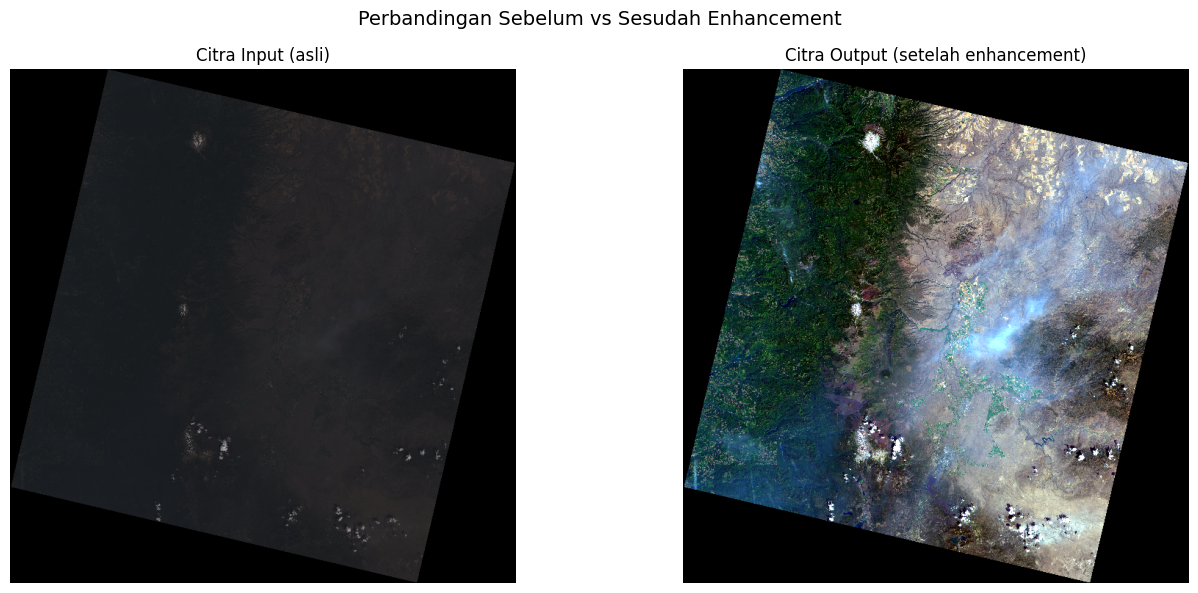

In [10]:
# Konversi ke uint16 [0, 65535]
bgr_out_16 = (bgr_enhanced * 65535).astype(np.uint16)

# Simpan citra
success = cv2.imwrite(OUTPUT_PATH, bgr_out_16)
print("Citra output disimpan ke:", OUTPUT_PATH, "| Status:", success)

# thumbnail untuk keperluan visualisasi cepat
def make_thumb(bgr_img, size=700):
    if bgr_img.dtype == np.uint16:
        bgr8 = (bgr_img / 256).astype(np.uint8)
    elif bgr_img.dtype in [np.float32, np.float64]:
        bgr8 = (np.clip(bgr_img, 0, 1) * 255).astype(np.uint8)
    else:
        bgr8 = bgr_img.astype(np.uint8)
    s = size / max(bgr8.shape[:2])
    t = cv2.resize(bgr8, (0, 0), fx=s, fy=s)
    return cv2.cvtColor(t, cv2.COLOR_BGR2RGB)

thumb_in  = make_thumb(bgr_raw)
thumb_out = make_thumb(bgr_out_16)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(thumb_in)
axes[0].set_title("Citra Input (asli)", fontsize=12)
axes[0].axis("off")
axes[1].imshow(thumb_out)
axes[1].set_title("Citra Output (setelah enhancement)", fontsize=12)
axes[1].axis("off")
plt.suptitle("Perbandingan Sebelum vs Sesudah Enhancement", fontsize=14)
plt.tight_layout()
plt.show()


---

## 11. Perbandingan dengan Contoh Output Referensi


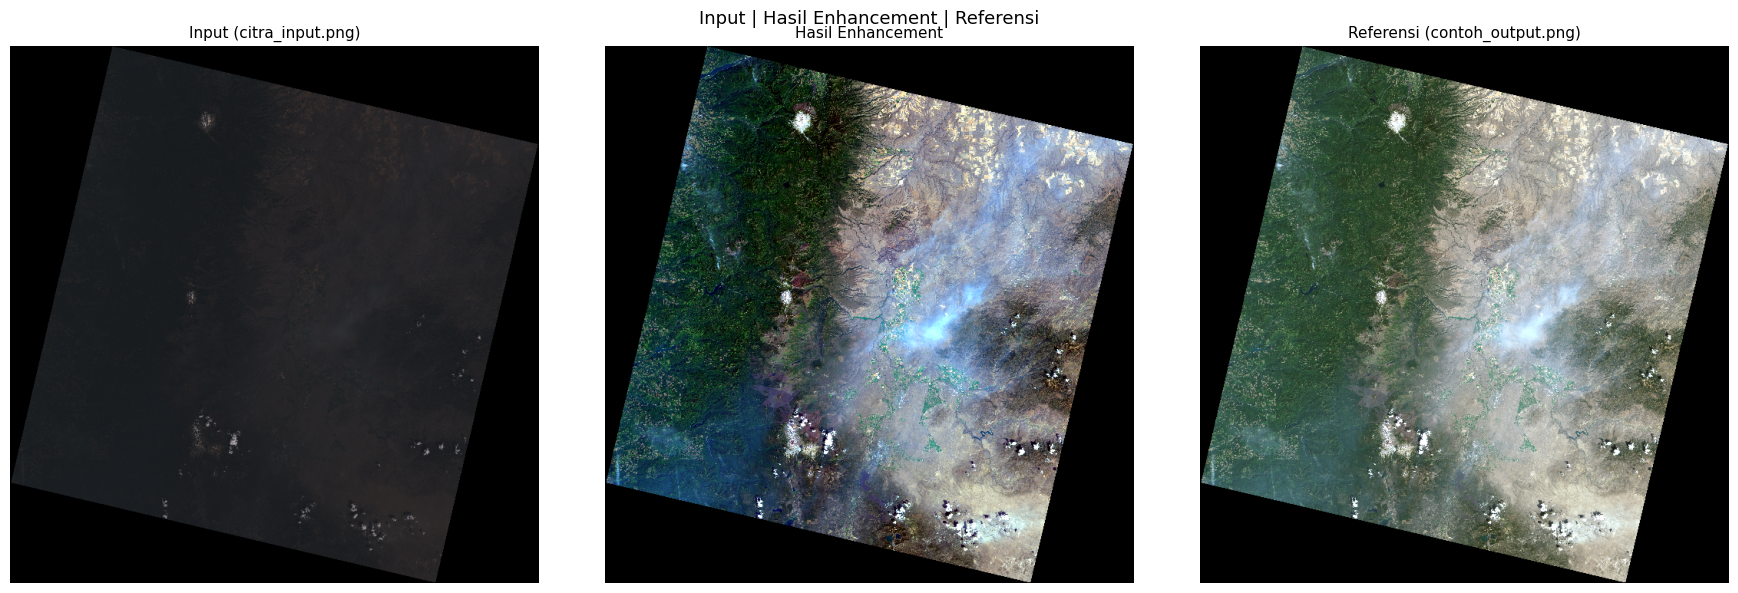

In [17]:
bgr_ref = cv2.imread(REFERENCE_PATH, cv2.IMREAD_UNCHANGED)

if bgr_ref is not None:
    thumb_ref = make_thumb(bgr_ref)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(thumb_in)
    axes[0].set_title("Input (citra_input.png)", fontsize=11)
    axes[0].axis("off")
    axes[1].imshow(thumb_out)
    axes[1].set_title("Hasil Enhancement", fontsize=11)
    axes[1].axis("off")
    axes[2].imshow(thumb_ref)
    axes[2].set_title("Referensi (contoh_output.png)", fontsize=11)
    axes[2].axis("off")
    plt.suptitle("Input | Hasil Enhancement | Referensi", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("File referensi tidak ditemukan:", REFERENCE_PATH)


---

## 12. Perbandingan Histogram (Sebelum vs Sesudah)

Histogram yang lebih tersebar luas menunjukkan distribusi nilai piksel yang lebih merata — tanda peningkatan kontras berhasil.


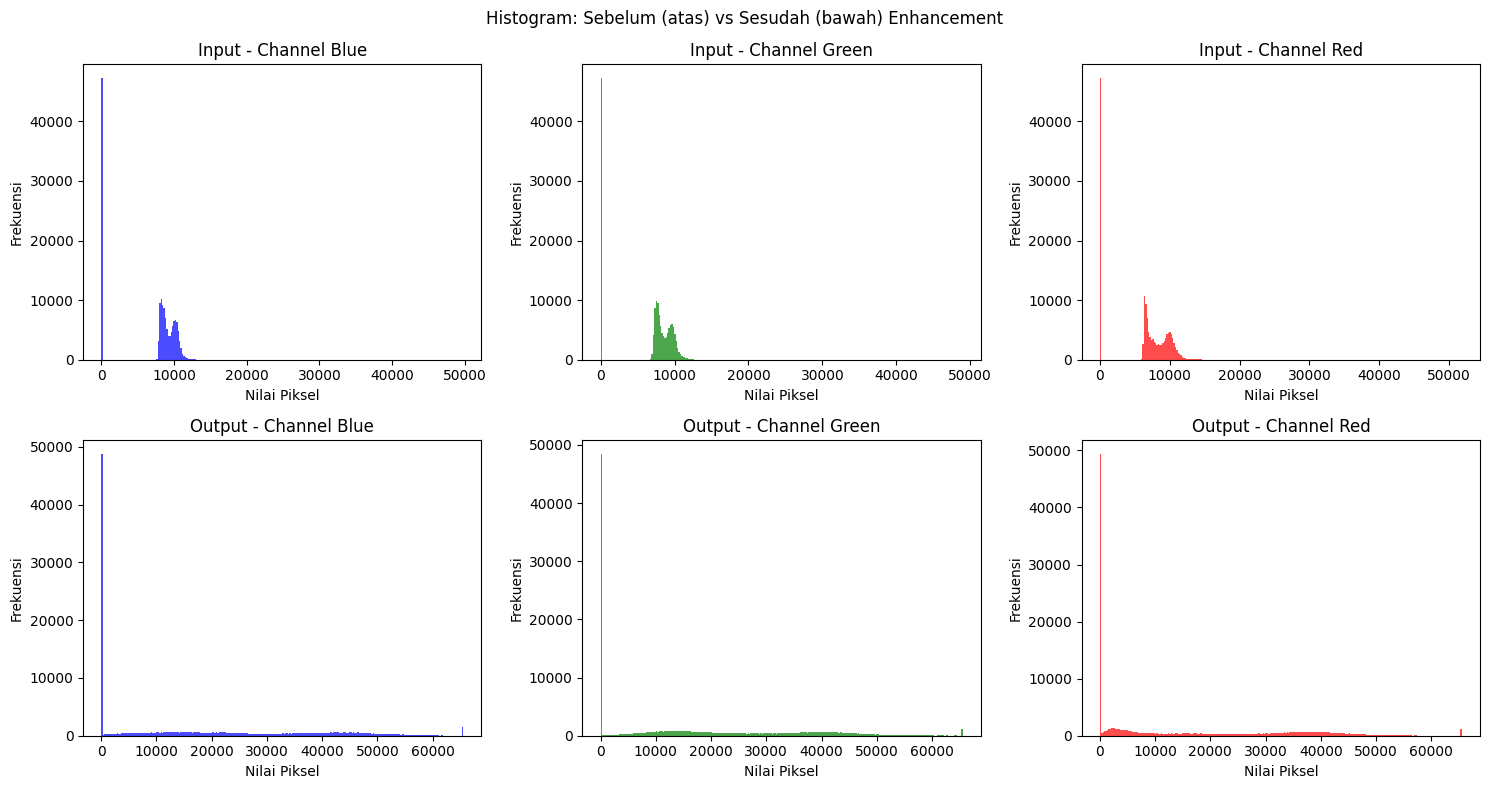

In [12]:
# Subsample untuk kecepatan komputasi
sub_in  = bgr_raw[::20, ::20]
sub_out = bgr_out_16[::20, ::20]

ch_names = ["Blue", "Green", "Red"]
colors   = ["blue", "green", "red"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, (name, color) in enumerate(zip(ch_names, colors)):
    axes[0, i].hist(sub_in[:, :, i].flatten(), bins=256, color=color, alpha=0.7)
    axes[0, i].set_title("Input - Channel " + name)
    axes[0, i].set_xlabel("Nilai Piksel")
    axes[0, i].set_ylabel("Frekuensi")

    axes[1, i].hist(sub_out[:, :, i].flatten(), bins=256, color=color, alpha=0.7)
    axes[1, i].set_title("Output - Channel " + name)
    axes[1, i].set_xlabel("Nilai Piksel")
    axes[1, i].set_ylabel("Frekuensi")

plt.suptitle("Histogram: Sebelum (atas) vs Sesudah (bawah) Enhancement", fontsize=12)
plt.tight_layout()
plt.show()


---

## 13. Evaluasi Kuantitatif (MSE & PSNR)

$$MSE = \frac{1}{N} \sum_{i=1}^{N} (I_i - O_i)^2$$

$$PSNR = 10 \log_{10}\left(\frac{MAX^2}{MSE}\right)$$




In [13]:
if bgr_ref is not None and bgr_ref.shape == bgr_out_16.shape:
    diff = bgr_out_16.astype(np.float64) - bgr_ref.astype(np.float64)
    mse  = float(np.mean(diff**2))
    MAX  = 65535.0
    psnr = 10 * np.log10(MAX**2 / mse) if mse > 0 else float("inf")
    mae  = float(np.mean(np.abs(diff)))
    print("=== Evaluasi Kuantitatif ===")
    print("  MSE  =", round(mse, 2))
    print("  PSNR =", round(psnr, 2), "dB")
    print("  MAE  =", round(mae, 2))
else:
    print("Evaluasi internal – Statistik Citra Output:")
    print("  Min :", int(bgr_out_16.min()))
    print("  Max :", int(bgr_out_16.max()))
    print("  Mean:", round(float(bgr_out_16.mean()), 1))
    print("  Std :", round(float(bgr_out_16.std()), 1))


Evaluasi internal – Statistik Citra Output:
  Min : 0
  Max : 65535
  Mean: 17942.5
  Std : 18130.5


---

## 14. Kesimpulan

Tahapan:
1. **Contrast Stretching**:  Pemetaan percentile 1%–99% memperluas rentang dinamis citra
2. **Konversi ke HSI**: Memisahkan komponen warna (H, S) dari kecerahan (I) |
3. **Gamma Correction (γ=0.80)**: Mencerahkan area gelap secara non-linear pada Intensity
4. **Saturation Boost (×1.35)**: Memperkuat warna setelah kecerahan ditingkatkan
5. **Konversi ke RGB** Mengembalikan HSI menjadi RGB menggunakan rumus HSI→RGB per-sektor

**Alasan pemilihan ruang warna HSI:**
- Pengolahan langsung pada channel RGB menyebabkan *hue shift* yang tidak natural.
- HSI memungkinkan enhancement Intensity (I) dan Saturation (S) dilakukan **secara mandiri** tanpa mengubah Hue (H).
- Sesuai teori *Color Image Processing* dari Gonzalez & Woods (referensi kuliah PCVK Week 6).
